In [51]:
import importlib
import tqec.computation.prism
import tqec.computation.pipe_prism
import tqec.computation.prism_graph

importlib.reload(tqec.computation.prism)
importlib.reload(tqec.computation.pipe_prism)
importlib.reload(tqec.computation.prism_graph)

from tqec.computation.prism import BasisPrism, Position3DHex, ZXPrism
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph

In [52]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection


def plot_position_dict(
    data: dict[str, list] | None = None,
    paths: list[list] | None = None,
    star_op: list[list] | None = None,
    dct_others: list[list] | None = None
) -> plt.Figure:
    """Plot Position3DHex positions using their to_euclidean coords.
    Args:
        data:    dict[str, list[Position3DHex]] — each key is a label, plotted as scattered dots.
                =bdry of traingle
        paths:   list[list[Position3DHex]] — each inner list plotted with its own color,
                 dots at each position and a line connecting them in list order,
                 with a closing line from last back to first.
                 = stabilizers
        star_op: list[list[Position3DHex]] — each inner list plotted as black crosses.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    n_data  = len(data)  if data  is not None else 0
    n_paths = len(paths) if paths is not None else 0
    n_total = n_data + n_paths

    def rainbow(i: int) -> tuple:
        return cm.rainbow(i / max(n_total - 1, 1))

    color_idx = 0


    if paths is not None:
        for i, positions in enumerate(paths):
            if not positions:
                continue
            if len(positions) == 2:
                color = "black"
            else:
                color = rainbow(color_idx); color_idx += 1
            xs = [p.to_euclidean()[0] for p in positions]
            ys = [p.to_euclidean()[1] for p in positions]
            # Draw transparent filled polygon
            poly = Polygon(list(zip(xs, ys)), closed=True,
                        facecolor=(*color[:3], 0.5) if color != "black" else (0, 0, 0, 0.2),
                        edgecolor=color, linewidth=1.5, zorder=2)
            ax.add_patch(poly)
            ax.scatter(xs, ys, color=color, s=60, zorder=3)
            for p, x, y in zip(positions, xs, ys):
                ax.text(x, y, f"({p.x},{p.y})", fontsize=7)

    if dct_others is not None:
        all_position_lists = [positions for others in dct_others.values() for positions in others if positions]
        tab20 = cm.get_cmap("tab20", max(len(all_position_lists), 1))
        for idx, positions in enumerate(all_position_lists):
            color = tab20(idx / max(len(all_position_lists) - 1, 1))
            xs = [p.to_euclidean()[0] for p in positions]
            ys = [p.to_euclidean()[1] for p in positions]
            ax.plot(xs + [xs[0]], ys + [ys[0]], color=color, linewidth=1.5, zorder=2)
            ax.scatter(xs, ys, color=color, s=60, zorder=3)
            for p, x, y in zip(positions, xs, ys):
                ax.text(x, y, f"({p.x},{p.y})", fontsize=7)


    if data is not None:
        for label, positions in data.items():
            color = rainbow(color_idx); color_idx += 1
            xs = [p.to_euclidean()[0] for p in positions]
            ys = [p.to_euclidean()[1] for p in positions]
            ax.scatter(xs, ys, color=color, label=label, s=80, zorder=3)
            for p, x, y in zip(positions, xs, ys):
                ax.annotate(f"({p.x},{p.y})", (x, y), textcoords="offset points",
                            xytext=(4, 4), fontsize=7)

    if star_op is not None:
        xs = [p.to_euclidean()[0] for p in star_op]
        ys = [p.to_euclidean()[1] for p in star_op]
        ax.scatter(xs, ys, color="black", marker="x", s=80, linewidths=1.5, zorder=4)

    ax.set_aspect("equal")
    ax.legend()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Position3DHex boundary vertices")
    plt.tight_layout()

In [53]:
d = 17
left_corner = Position3DHex(0,0,0)
triangle_type = "upwards"
dct = ZXPrism.patch_triangle_bdry(d, left_corner, triangle_type)

print(dct)

{'a': [Position3DHex(x=16, y=16, z=0), Position3DHex(x=15, y=15, z=0), Position3DHex(x=14, y=14, z=0), Position3DHex(x=13, y=13, z=0), Position3DHex(x=12, y=12, z=0), Position3DHex(x=11, y=11, z=0), Position3DHex(x=10, y=10, z=0), Position3DHex(x=9, y=9, z=0), Position3DHex(x=8, y=8, z=0), Position3DHex(x=7, y=7, z=0), Position3DHex(x=6, y=6, z=0), Position3DHex(x=5, y=5, z=0), Position3DHex(x=4, y=4, z=0), Position3DHex(x=3, y=3, z=0), Position3DHex(x=2, y=2, z=0), Position3DHex(x=1, y=1, z=0), Position3DHex(x=0, y=0, z=0)], 'b': [Position3DHex(x=0, y=0, z=0), Position3DHex(x=3, y=-1, z=0), Position3DHex(x=4, y=-2, z=0), Position3DHex(x=7, y=-3, z=0), Position3DHex(x=8, y=-4, z=0), Position3DHex(x=11, y=-5, z=0), Position3DHex(x=12, y=-6, z=0), Position3DHex(x=15, y=-7, z=0), Position3DHex(x=16, y=-8, z=0), Position3DHex(x=19, y=-9, z=0), Position3DHex(x=20, y=-10, z=0), Position3DHex(x=23, y=-11, z=0), Position3DHex(x=24, y=-12, z=0), Position3DHex(x=27, y=-13, z=0), Position3DHex(x=

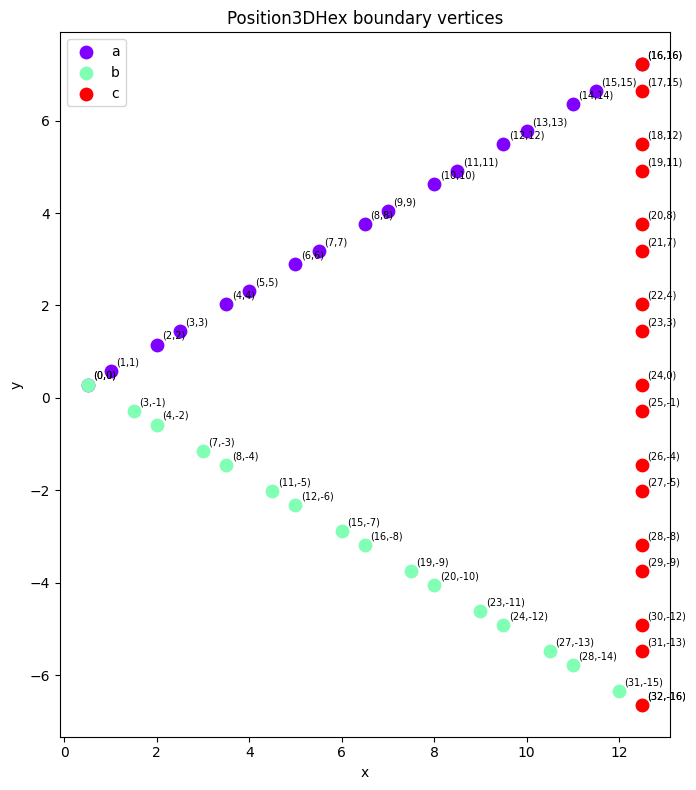

In [54]:
plot_position_dict(dct)

In [55]:
plaqs = ZXPrism.patch_adjacent_bulk_stabilizers(Position3DHex(2,2,0))
print(plaqs)

[[Position3DHex(x=2, y=2, z=0), Position3DHex(x=3, y=3, z=0), Position3DHex(x=4, y=2, z=0), Position3DHex(x=5, y=1, z=0), Position3DHex(x=4, y=0, z=0), Position3DHex(x=3, y=1, z=0)], [Position3DHex(x=2, y=2, z=0), Position3DHex(x=3, y=3, z=0), Position3DHex(x=2, y=4, z=0), Position3DHex(x=1, y=5, z=0), Position3DHex(x=0, y=4, z=0), Position3DHex(x=1, y=3, z=0)], [Position3DHex(x=2, y=2, z=0), Position3DHex(x=1, y=3, z=0), Position3DHex(x=0, y=2, z=0), Position3DHex(x=1, y=1, z=0), Position3DHex(x=2, y=0, z=0), Position3DHex(x=3, y=1, z=0)]]


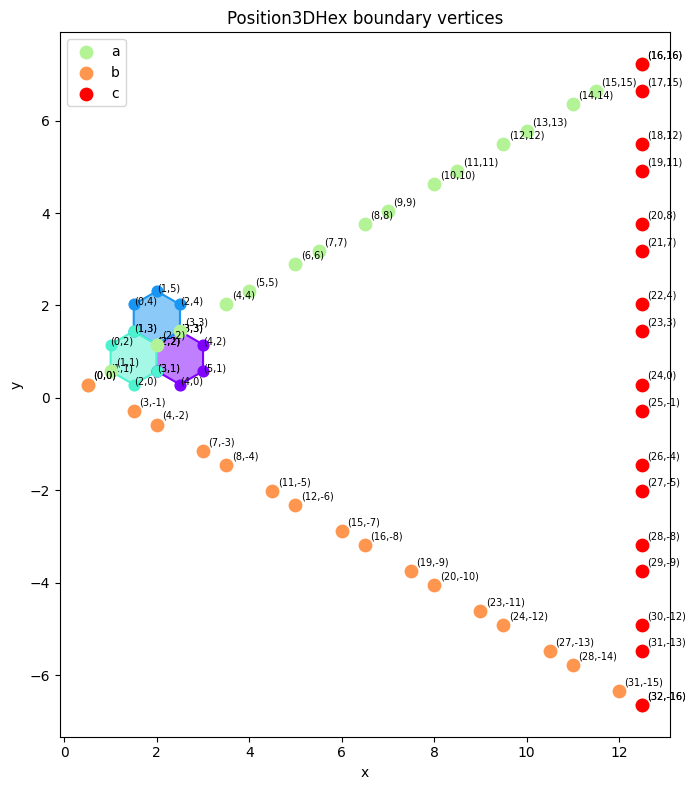

In [56]:
plot_position_dict(dct, plaqs)
#i=2
#plot_position_dict(dct, [plaqs[i]])

#for pos in plaqs[i]:
    #print(ZXPrism.check_within_bdrys(pos, dct, d))

In [57]:
stabilizers, _ = ZXPrism.patch_stabilizers(d, "upwards", left_corner, [])

number of single type stabilizers: 108.0
len stabilizers 108


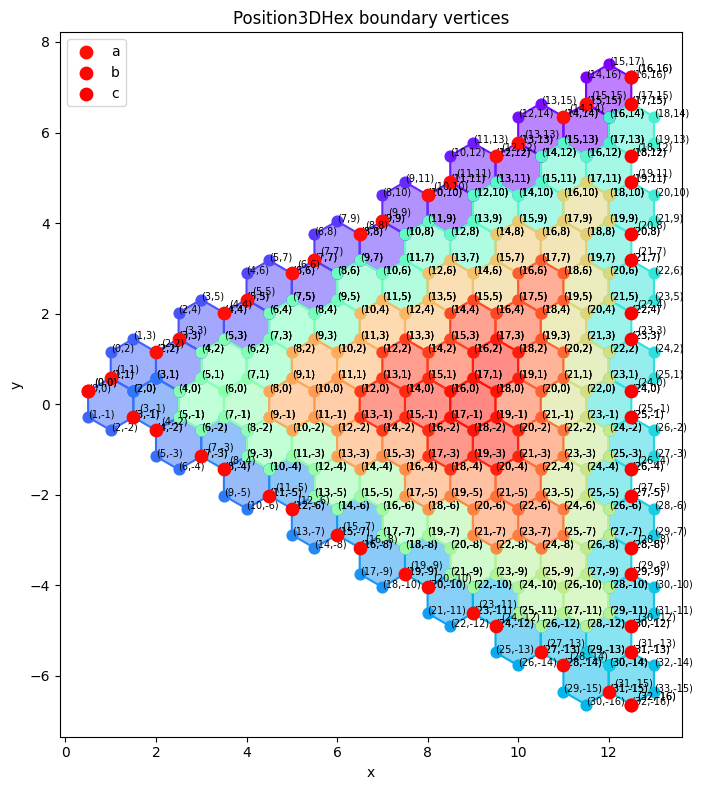

In [58]:
plot_position_dict(dct, stabilizers)
print("number of single type stabilizers:", (3*(d**2-1))/8)
print("len stabilizers", len(stabilizers))

108


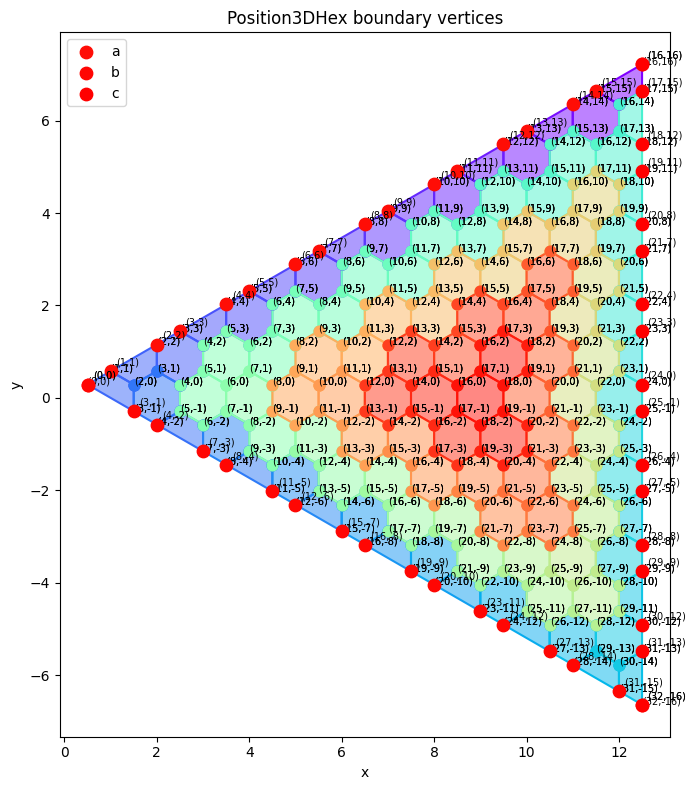

In [59]:
stabilizers, _ = ZXPrism.patch_stabilizers(d, "upwards",left_corner, ["a", "b", "c"])
plot_position_dict(dct, stabilizers)
print(len(stabilizers))

In [60]:
star_op = ZXPrism.star_operator_patch(triangle_type, dct)
print(type(star_op[1]))

<class 'tqec.computation.prism.Position3DHex'>


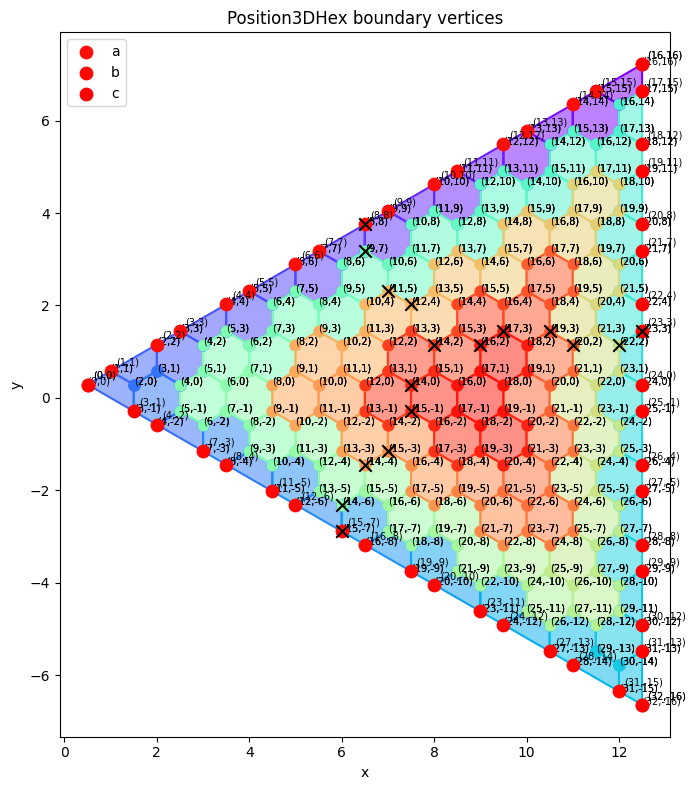

In [61]:
plot_position_dict(dct, stabilizers, star_op)

### "Downward" triangle

In [62]:
d = 15
left_corner = Position3DHex(0,0,0)
triangle_type = "downwards"
dct = ZXPrism.patch_triangle_bdry(d, left_corner, triangle_type)

print(dct)

{'a': [Position3DHex(x=14, y=14, z=0), Position3DHex(x=13, y=13, z=0), Position3DHex(x=12, y=12, z=0), Position3DHex(x=11, y=11, z=0), Position3DHex(x=10, y=10, z=0), Position3DHex(x=9, y=9, z=0), Position3DHex(x=8, y=8, z=0), Position3DHex(x=7, y=7, z=0), Position3DHex(x=6, y=6, z=0), Position3DHex(x=5, y=5, z=0), Position3DHex(x=4, y=4, z=0), Position3DHex(x=3, y=3, z=0), Position3DHex(x=2, y=2, z=0), Position3DHex(x=1, y=1, z=0), Position3DHex(x=0, y=0, z=0)], 'b': [Position3DHex(x=-14, y=28, z=0), Position3DHex(x=-11, y=27, z=0), Position3DHex(x=-10, y=26, z=0), Position3DHex(x=-7, y=25, z=0), Position3DHex(x=-6, y=24, z=0), Position3DHex(x=-3, y=23, z=0), Position3DHex(x=-2, y=22, z=0), Position3DHex(x=1, y=21, z=0), Position3DHex(x=2, y=20, z=0), Position3DHex(x=5, y=19, z=0), Position3DHex(x=6, y=18, z=0), Position3DHex(x=9, y=17, z=0), Position3DHex(x=10, y=16, z=0), Position3DHex(x=13, y=15, z=0), Position3DHex(x=14, y=14, z=0)], 'c': [Position3DHex(x=0, y=0, z=0), Position3DH

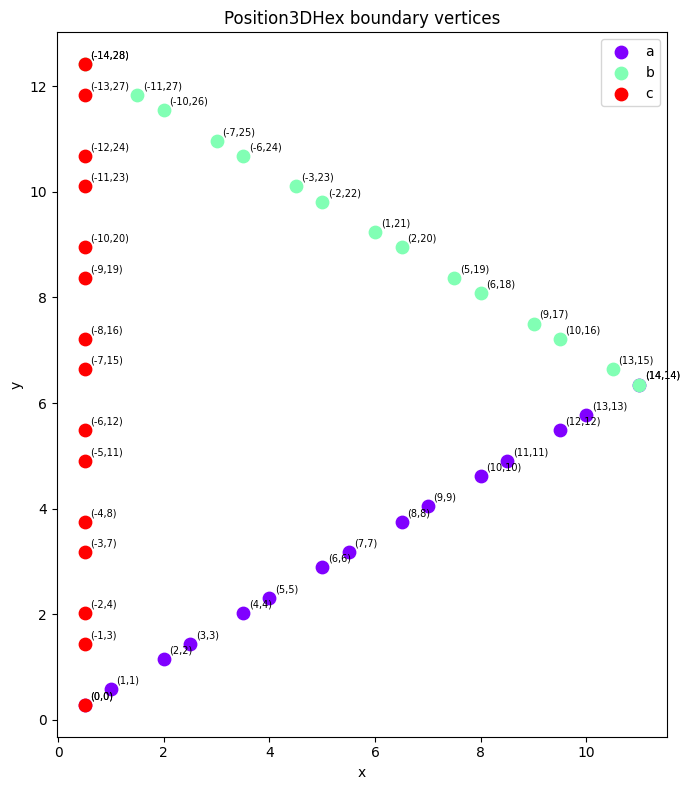

In [63]:
plot_position_dict(dct)

In [64]:
stabilizers, _ = ZXPrism.patch_stabilizers(d, triangle_type, left_corner, ["c"])

number of single type stabilizers: 84.0
len stabilizers 84


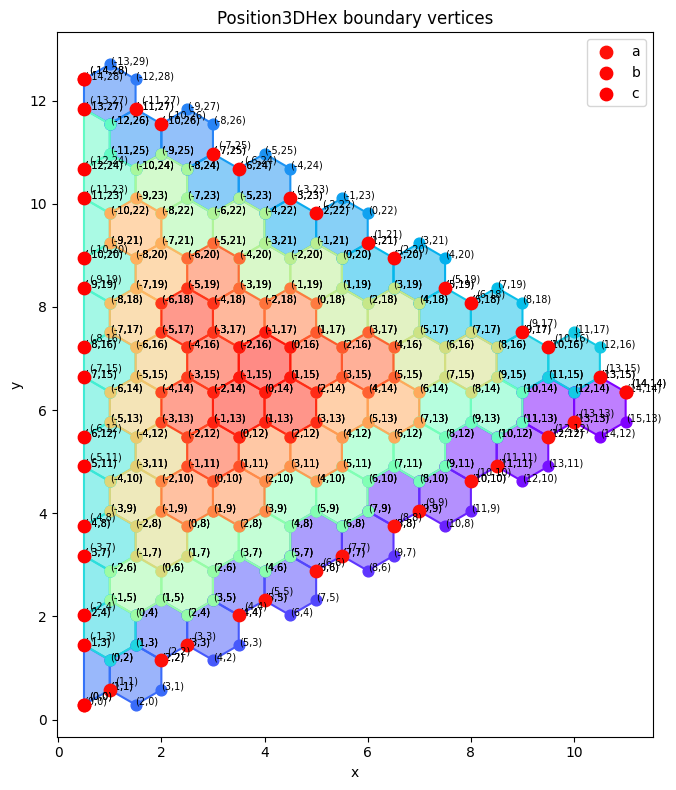

In [65]:
plot_position_dict(dct, stabilizers)
print("number of single type stabilizers:", (3*(d**2-1))/8)
print("len stabilizers", len(stabilizers))

In [66]:
star_op = ZXPrism.star_operator_patch(triangle_type, dct)

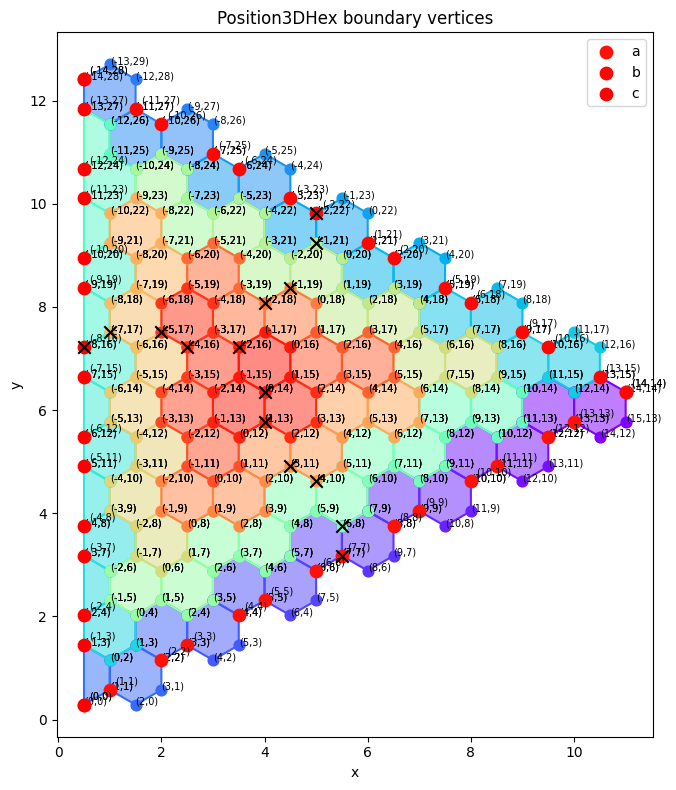

In [67]:
plot_position_dict(dct, stabilizers, star_op)

# Extract stabilizers from a PrismGraph structure

In [68]:
g = PrismGraph("Id")

prisms = [
    (Position3DHex(0, 0, 0), "PORT", "in"),
    (Position3DHex(1, 1, 0), "ZZ", ""),
    (Position3DHex(2, 0, 0), "ZZ", ""),
    (Position3DHex(3, 1, 0), "ZZ", ""),
    (Position3DHex(2, 2, 0), "ZZ", ""),
    (Position3DHex(1, 3, 0), "PORT", "out"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [69]:
pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[3][0], prisms[4][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[4][0], prisms[5][0], pipe_kind)

In [70]:
g.view_as_html()

In [75]:
z=0
d=11
stabs_x, stabs_z, allweight2, dct_others = g.stabilizers_timeslice(z,d)

Position3DHex(x=10, y=0, z=0)
Position3DHex(x=22, y=0, z=0)
Position3DHex(x=34, y=-12, z=0)
Position3DHex(x=46, y=-12, z=0)
Position3DHex(x=46, y=0, z=0)
Position3DHex(x=34, y=12, z=0)
Position3DHex(x=0, y=0, z=0)
Position3DHex(x=22, y=-10, z=0)
Position3DHex(x=24, y=-12, z=0)
Position3DHex(x=46, y=-22, z=0)
Position3DHex(x=36, y=0, z=0)
Position3DHex(x=34, y=2, z=0)
number of stabs 45
number of stabs 45
number of stabs 45
number of stabs 45
number of stabs 45
number of stabs 45
---------pipe----------- PrismPipe(u=Prism(position=Position3DHex(x=1, y=1, z=0), kind=ZXPrism(prep=<BasisPrism.Z: 'Z'>, meas=<BasisPrism.Z: 'Z'>), label=''), v=Prism(position=Position3DHex(x=0, y=0, z=0), kind=<tqec.computation.prism.Port object at 0x7b82687e43d0>, label='in'), kind=PrismPipeKind(hor=<BasisPrism.Z: 'Z'>, ver=<BasisPrism.X: 'X'>, has_hadamard=False))
pos1, pos2 Position3DHex(x=22, y=-10, z=0) Position3DHex(x=20, y=-10, z=0)
pos1_neighbor_weight2 [[Position3DHex(x=21, y=-9, z=0), Position3DHex(x

/tmp/ipykernel_488340/396928283.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


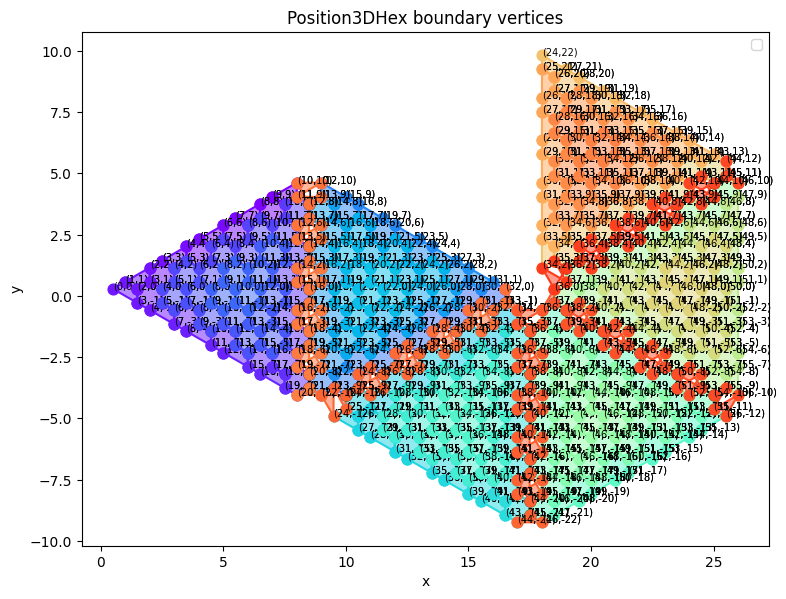

In [76]:
plot_position_dict(None, stabs_x)

In [77]:
for bdry in dct_others.values():
    print("==========")
    for el in bdry:
        print(len(el))
        print(el)

2
[Position3DHex(x=21, y=-9, z=0), Position3DHex(x=20, y=-8, z=0)]
3
[Position3DHex(x=22, y=-10, z=0), Position3DHex(x=20, y=-10, z=0), Position3DHex(x=21, y=-9, z=0)]
2
[Position3DHex(x=19, y=-5, z=0), Position3DHex(x=18, y=-4, z=0)]
6
[Position3DHex(x=21, y=-7, z=0), Position3DHex(x=19, y=-7, z=0), Position3DHex(x=20, y=-6, z=0), Position3DHex(x=18, y=-6, z=0), Position3DHex(x=20, y=-8, z=0), Position3DHex(x=19, y=-5, z=0)]
2
[Position3DHex(x=17, y=-1, z=0), Position3DHex(x=16, y=0, z=0)]
6
[Position3DHex(x=19, y=-3, z=0), Position3DHex(x=17, y=-3, z=0), Position3DHex(x=18, y=-2, z=0), Position3DHex(x=16, y=-2, z=0), Position3DHex(x=18, y=-4, z=0), Position3DHex(x=17, y=-1, z=0)]
2
[Position3DHex(x=15, y=3, z=0), Position3DHex(x=14, y=4, z=0)]
6
[Position3DHex(x=17, y=1, z=0), Position3DHex(x=15, y=1, z=0), Position3DHex(x=16, y=2, z=0), Position3DHex(x=14, y=2, z=0), Position3DHex(x=16, y=0, z=0), Position3DHex(x=15, y=3, z=0)]
2
[Position3DHex(x=13, y=7, z=0), Position3DHex(x=12, y

/tmp/ipykernel_488340/396928283.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


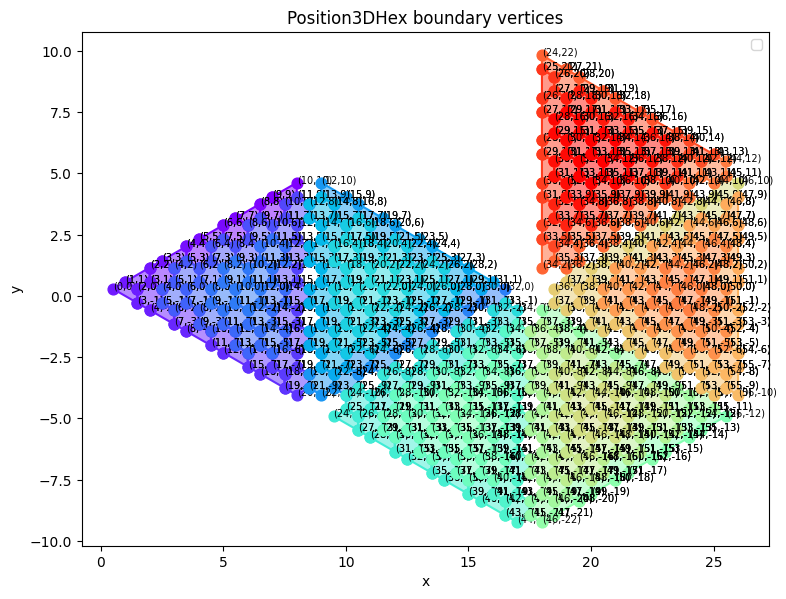

In [78]:
plot_position_dict(None, stabs_z)

In [79]:
g._graph.nodes

NodeView((Position3DHex(x=0, y=0, z=0), Position3DHex(x=1, y=1, z=0), Position3DHex(x=2, y=0, z=0), Position3DHex(x=3, y=1, z=0), Position3DHex(x=2, y=2, z=0), Position3DHex(x=1, y=3, z=0)))

### red junction

In [85]:
g = PrismGraph("red junction")

prisms = [
    (Position3DHex(0,0,1), "NN", "middle"),
    (Position3DHex(0,0,2), "Port", "top"),
    (Position3DHex(0,0,0), "Port", "bottom"),
    (Position3DHex(1,1,1), "Port", "left"),
    (Position3DHex(-1,1,1), "Port", "right"),
    (Position3DHex(1,-1,1), "Port", "down"),
]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [86]:
#middle bottom
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[2][0], pipe_kind)

#middle top
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

#middle left
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[3][0], pipe_kind)

#middle right
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[4][0], pipe_kind)

#middle down
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[0][0], prisms[5][0], pipe_kind)

In [87]:
g.view_as_html()

In [88]:
z=1
d=9
stabs_x, stabs_z, _, _ = g.stabilizers_timeslice(z,d)

Position3DHex(x=8, y=0, z=1)
Position3DHex(x=18, y=0, z=1)
Position3DHex(x=-2, y=10, z=1)
Position3DHex(x=8, y=-10, z=1)
Position3DHex(x=0, y=0, z=1)
Position3DHex(x=18, y=-8, z=1)
Position3DHex(x=-2, y=2, z=1)
Position3DHex(x=8, y=-18, z=1)
number of stabs 30
number of stabs 30
number of stabs 30
number of stabs 30
---------pipe----------- PrismPipe(u=Prism(position=Position3DHex(x=1, y=1, z=1), kind=<tqec.computation.prism.Port object at 0x7b82342f5930>, label='left'), v=Prism(position=Position3DHex(x=0, y=0, z=1), kind=ZXPrism(prep=<BasisPrism.N: 'N'>, meas=<BasisPrism.N: 'N'>), label='middle'), kind=PrismPipeKind(hor=<BasisPrism.X: 'X'>, ver=<BasisPrism.Z: 'Z'>, has_hadamard=False))
pos1, pos2 Position3DHex(x=18, y=-8, z=1) Position3DHex(x=16, y=-8, z=1)
pos1_neighbor_weight2 [[Position3DHex(x=17, y=-7, z=1), Position3DHex(x=16, y=-6, z=1)]]
pos2_neighbor_weight2 [[Position3DHex(x=17, y=-7, z=1), Position3DHex(x=16, y=-6, z=1)]]
case weight 2 neighbor
pos1, pos2 Position3DHex(x=17,

/tmp/ipykernel_488340/396928283.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


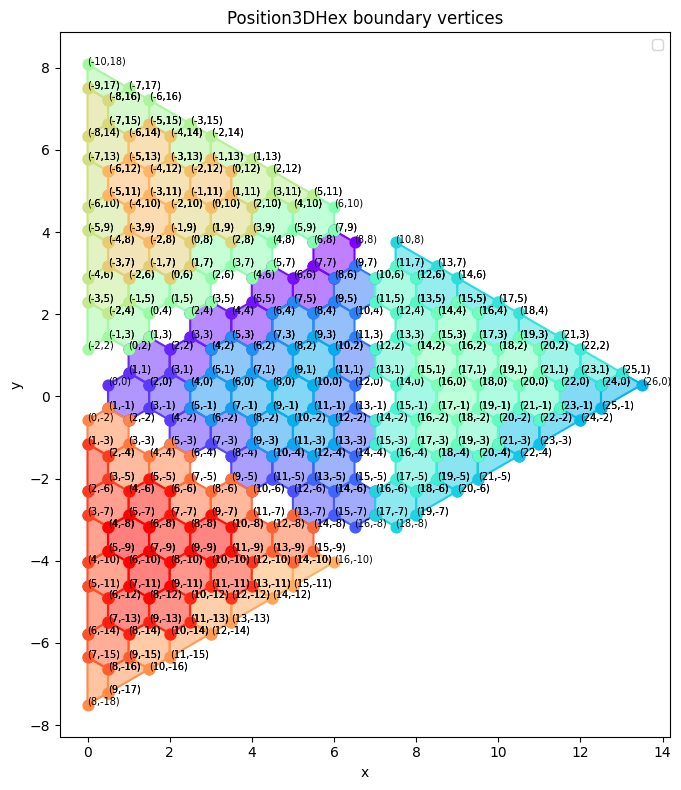

In [89]:
plot_position_dict(None, stabs_x)

/tmp/ipykernel_488340/396928283.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


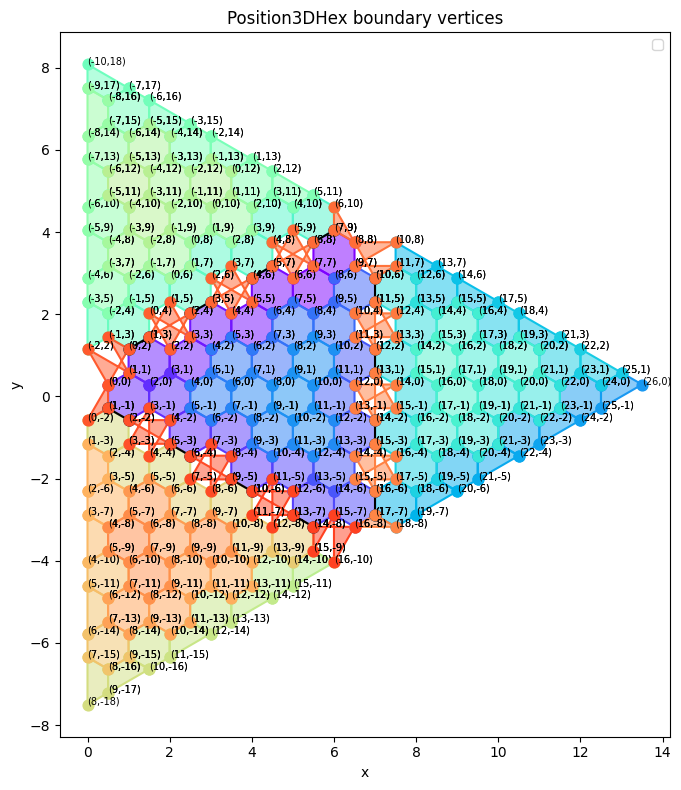

In [90]:
plot_position_dict(None, stabs_z)